# Diabetes Prediction


## 1. Problem Statement

Diabetes is a chronic metabolic disorder that affects millions of people worldwide and is a leading cause of cardiovascular disease, kidney failure, vision impairment, and other serious health complications. Early detection is essential for initiating timely treatment and preventive interventions; however, traditional screening methods often require clinical examinations, laboratory investigations, and specialist consultation, which may not always be accessible or cost-effective.

The availability of healthcare and lifestyle data presents an opportunity to develop intelligent predictive systems that can identify individuals at risk of diabetes before severe complications arise. The Diabetes Health Indicators Dataset contains demographic, behavioral, and health-related attributes that can be utilized to build accurate predictive models.

The problem addressed in this project is to develop a machine learning model capable of accurately classifying individuals as diabetic or non-diabetic based on their health indicators. The system aims to analyze multiple risk factors, identify the most influential predictors of diabetes, and provide a reliable decision-support tool that can assist healthcare professionals in early screening and preventive healthcare planning.

## 2. About the Data

**Source:** https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

| Column | Meaning |
|---|---|
| Diabetes_binary | Target:0 = no diabetes 1 = prediabetes or diabetes |
| HighBP | 0 = no high BP<br><br> 1 = high BP |
| HighChol | 0 = no high cholesterol<br><br> 1 = high cholesterol |
| CholCheck | 0 = no cholesterol check in 5 years<br><br> 1 = yes cholesterol check in 5 years |
| BMI | Body Mass Index |
| Smoker | Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] <br><br>0 = no<br><br> 1 = yes |
| Stroke | (Ever told) you had a stroke.<br><br> 0 = no <br><br>1 = yes |
| HeartDiseaseorAttack | coronary heart disease (CHD) or myocardial infarction (MI)<br><br> 0 = no<br><br> 1 = yes |
| PhysActivity | physical activity in past 30 days - not including job<br><br> 0 = no<br><br> 1 = yes |
| Fruits | Consume Fruit 1 or more times per day <br><br>0 = no <br><br>1 = yes |
| Veggies | Consume Vegetables 1 or more times per day <br><br>0 = no<br><br> 1 = yes |
| HvyAlcoholConsump | Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 <br><br> drinks per week) <br><br>0 = no <br><br>1 = yes |
| AnyHealthcare | Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc.<br><br> 0 = no<br><br> 1 = yes |
| NoDocbcCost | Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?<br><br> 0 = no<br><br> 1 = yes |
| GenHlth | Would you say that in general your health is: scale 1-5 <br><br>1 = excellent<br><br> 2 = very good<br><br> 3 = good <br><br>4 = fair <br><br>5 = poor |
| MentHlth | Now thinking about your mental health, which includes stress, depression, and problems with emotions,<br><br> for how many days during the past 30 days was your mental health not good? scale 1-30 days |
| PhysHlth | Now thinking about your physical health, which includes physical illness and injury, for how many days<br><br> during the past 30 days was your physical health not good? scale 1-30 days |
| DiffWalk | Do you have serious difficulty walking or climbing stairs?<br><br> 0 = no<br><br> 1 = yes |
| Sex | 0 = female 1 = male |
| Age | 13-level age category (_AGEG5YR see codebook)<br><br> 1 = 18-24 <br><br>9 = 60-64<br><br> 13 = 80 or older |
| Education | Education level (EDUCA see codebook) scale 1-6 <br><br>1 = Never attended school or only kindergarten <br><br>2 = Grades 1 through 8 (Elementary) <br><br>3 = Grades 9 through 11 (Some high school) <br><br>4 = Grade 12 or GED (High school graduate) <br><br>5 = College 1 year to 3 years (Some college or technical school) <br><br>6 = College 4 years or more (College graduate) |
| Income | Income scale (INCOME2 see codebook) scale 1-8<br><br> 1 = less than \$10,000 <br><br> 5 = less than \$35,000<br><br> 8 = \$75,000 or more |



##**Importing Libraries**





In [727]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif

#from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [728]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [729]:
#importing the dataset
file_path = '/content/drive/MyDrive/AIML Project/Dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

## 3. Understanding the Data

In [730]:
df.shape

(70692, 22)

In [731]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [732]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [733]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [734]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [735]:
df.iloc[:, :11].describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,0.788774
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,0.408181
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [736]:
df.iloc[:, 11:].describe()

,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.042721,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.202228,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,0.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Verifying the values of each feature:

In [737]:
for col in df.columns:

    print(col)
    print(f'Unique value count = {df[col].nunique()}')
    print(f'Unique values = {np.sort(df[col].unique())}')
    print("-------------------")

Diabetes_binary
Unique value count = 2
Unique values = [0. 1.]
-------------------
HighBP
Unique value count = 2
Unique values = [0. 1.]
-------------------
HighChol
Unique value count = 2
Unique values = [0. 1.]
-------------------
CholCheck
Unique value count = 2
Unique values = [0. 1.]
-------------------
BMI
Unique value count = 80
Unique values = [12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.
 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.
 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83.
 84. 85. 86. 87. 89. 92. 95. 98.]
-------------------
Smoker
Unique value count = 2
Unique values = [0. 1.]
-------------------
Stroke
Unique value count = 2
Unique values = [0. 1.]
-------------------
HeartDiseaseorAttack
Unique value count = 2
Unique values = [0. 1.]
-------------------
PhysActivity
Unique value count = 2
Unique values = [0. 1.]
----

Range of each features

In [738]:
summary = df.agg(['min', 'max']).T

summary['dtype'] = df.dtypes
print(summary)

                       min   max    dtype
Diabetes_binary        0.0   1.0  float64
HighBP                 0.0   1.0  float64
HighChol               0.0   1.0  float64
CholCheck              0.0   1.0  float64
BMI                   12.0  98.0  float64
Smoker                 0.0   1.0  float64
Stroke                 0.0   1.0  float64
HeartDiseaseorAttack   0.0   1.0  float64
PhysActivity           0.0   1.0  float64
Fruits                 0.0   1.0  float64
Veggies                0.0   1.0  float64
HvyAlcoholConsump      0.0   1.0  float64
AnyHealthcare          0.0   1.0  float64
NoDocbcCost            0.0   1.0  float64
GenHlth                1.0   5.0  float64
MentHlth               0.0  30.0  float64
PhysHlth               0.0  30.0  float64
DiffWalk               0.0   1.0  float64
Sex                    0.0   1.0  float64
Age                    1.0  13.0  float64
Education              1.0   6.0  float64
Income                 1.0   8.0  float64


In [739]:
# Target feature distribution
df['Diabetes_binary'].value_counts()

,count
Diabetes_binary,
0.0,35346
1.0,35346


Checking for missing values:

In [740]:
df.isna().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


Checking duplicate records

In [741]:
# duplicate rows count
df.duplicated().sum()

np.int64(1635)

In [742]:
df[df.duplicated()]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
602,0.0,0.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
689,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
891,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
1092,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
1326,0.0,1.0,0.0,1.0,29.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69865,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
69939,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
70305,1.0,1.0,0.0,1.0,30.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,4.0,7.0
70591,1.0,1.0,1.0,1.0,30.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,6.0,8.0


## 4. EDA

In this dataset, BMI is the only continuous feature, so we will derive a new feature from BMI called BMI_Class to do better plots

In [743]:
df_eda = df.copy()

Defining BMI classes:

In [744]:
bins = [0, 18.5, 25, 30, 35, 40, np.inf]

bmi_order = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obesity I',
    'Obesity II',
    'Obesity III',
]

df_eda['BMI_Class'] = pd.cut(
    df['BMI'],
    bins=bins,
    labels=bmi_order,
    right=False,
)

Defining bins for MentHlth and PhysHlth to create groups for plotting

In [745]:
bins = [-1, 0, 5, 10, 20, 30]
ment_or_phy_health_orders = [
    '0 days',
    '1–5 days',
    '6–10 days',
    '11–20 days',
    '21–30 days'
]

df_eda['MentHlth_Group'] = pd.cut(df['MentHlth'], bins=bins, labels=ment_or_phy_health_orders)
df_eda['PhysHlth_Group'] = pd.cut(df['PhysHlth'], bins=bins, labels=ment_or_phy_health_orders)

In [746]:
df_eda.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_Class,MentHlth_Group,PhysHlth_Group
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,5.0,30.0,0.0,1.0,4.0,6.0,8.0,Overweight,1–5 days,21–30 days
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,12.0,6.0,8.0,Overweight,0 days,0 days
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,0.0,10.0,0.0,1.0,13.0,6.0,8.0,Overweight,0 days,6–10 days
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,1.0,11.0,6.0,8.0,Overweight,0 days,1–5 days
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,8.0,5.0,8.0,Overweight,0 days,0 days


Now let's categorize the features

In [747]:
binary_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'DiffWalk',
    'Sex',
]

In [748]:
binary_labels = {
    'HighBP': {0: 'No', 1: 'Yes'},
    'HighChol': {0: 'No', 1: 'Yes'},
    'CholCheck': {0: 'No', 1: 'Yes'},
    'Smoker': {0: 'No', 1: 'Yes'},
    'Stroke': {0: 'No', 1: 'Yes'},
    'HeartDiseaseorAttack': {0: 'No', 1: 'Yes'},
    'PhysActivity': {0: 'No', 1: 'Yes'},
    'Fruits': {0: 'No', 1: 'Yes'},
    'Veggies': {0: 'No', 1: 'Yes'},
    'HvyAlcoholConsump': {0: 'No', 1: 'Yes'},
    'AnyHealthcare': {0: 'No', 1: 'Yes'},
    'NoDocbcCost': {0: 'No', 1: 'Yes'},
    'DiffWalk': {0: 'No', 1: 'Yes'},
    'Sex': {0: 'Female', 1: 'Male'}
}

In [749]:
ordinal_features = [
    'Age',
    'Education',
    'Income',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
]

In [750]:
ordinal_labels = {
    'Age': {
        1: '18–24',
        2: '25–29',
        3: '30–34',
        4: '35–39',
        5: '40–44',
        6: '45–49',
        7: '50–54',
        8: '55–59',
        9: '60–64',
        10: '65–69',
        11: '70–74',
        12: '75–79',
        13: '80+',
    },
    'Education': {
        1: 'Kindergarten',
        2: 'Elementary',
        3: 'Some High School',
        4: 'High School/GED',
        5: 'Some College',
        6: 'College Graduate',
    },
    'Income': {
        1: '<$10K',
        2: '$10K–15K',
        3: '$15K–20K',
        4: '$20K–25K',
        5: '$25K–35K',
        6: '$35K–50K',
        7: '$50K–75K',
        8: '$75K+',
    },
    'GenHlth': {
        1: 'Excellent',
        2: 'Very Good',
        3: 'Good',
        4: 'Fair',
        5: 'Poor',
    }
}

In [751]:
cat_features = [
    'BMI_Class'
    'PhysHlth_Group',
    'MentHlth_Group',
]

In [752]:
cat_feature_order = {
    'BMI_Class': bmi_order,
    'PhysHlth_Group': ment_or_phy_health_orders,
    'MentHlth_Group': ment_or_phy_health_orders,
}

### 4.1 Univariate Analysis

Distribution of Diabetes

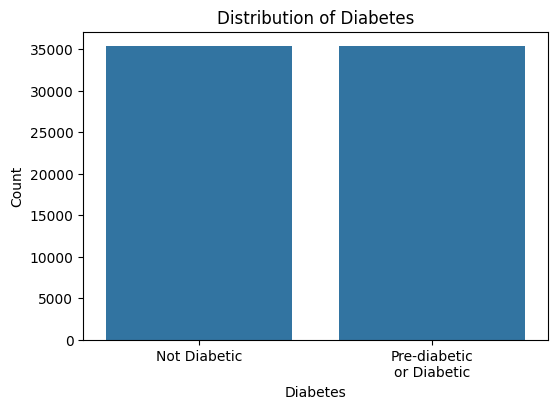

In [753]:
plt.figure(figsize=(6,4))

sns.countplot(x="Diabetes_binary", data=df_eda)
plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Diabetic", "Pre-diabetic\nor Diabetic"]
)
plt.show()

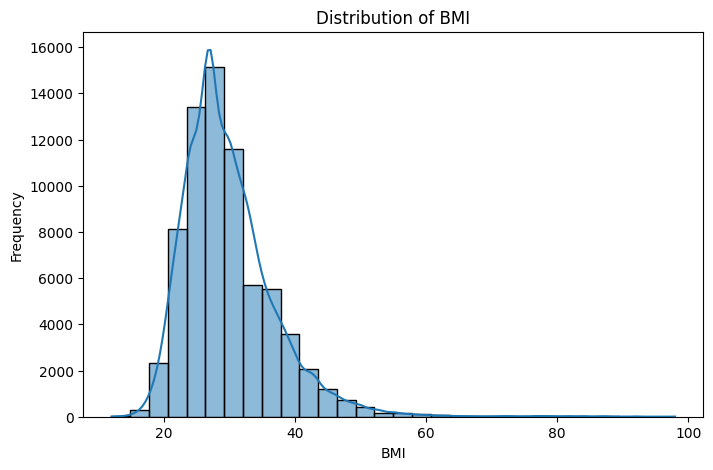

In [754]:
plt.figure(figsize=(8,5))

sns.histplot(df_eda["BMI"], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

It seems like there're outliers in the BMI

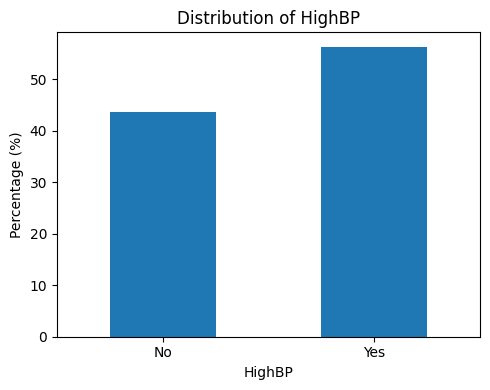

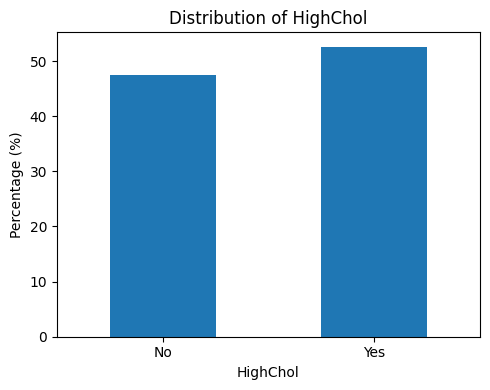

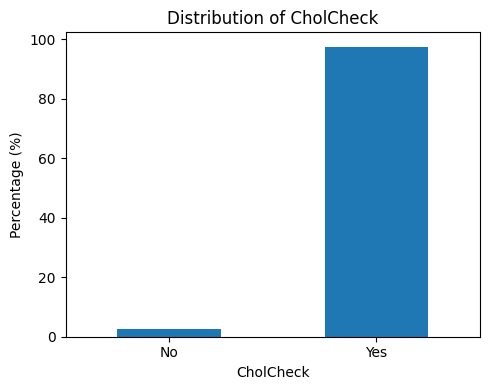

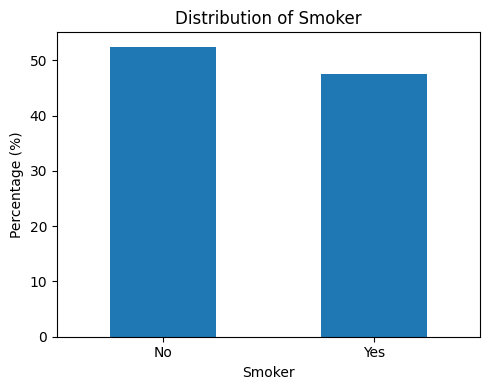

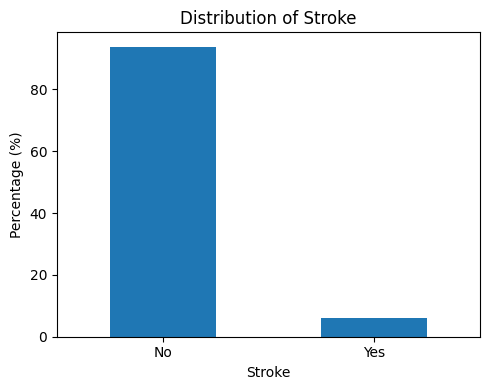

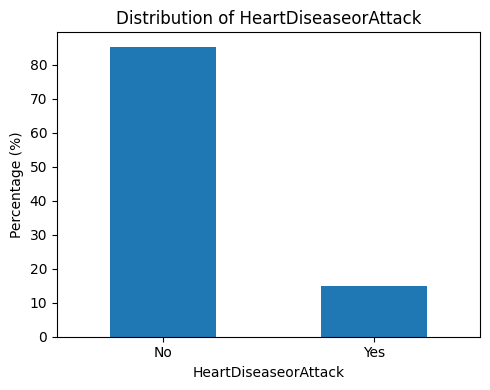

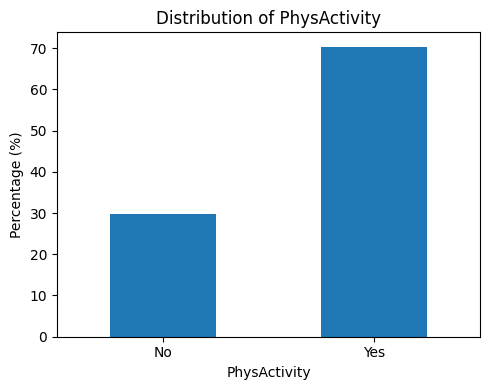

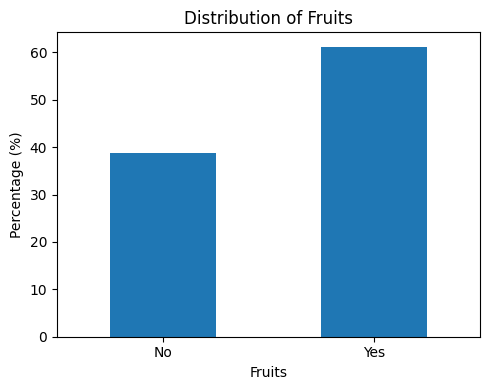

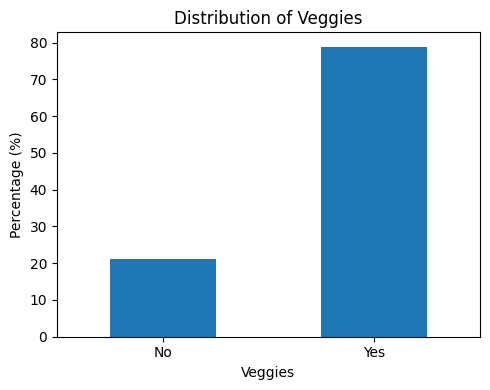

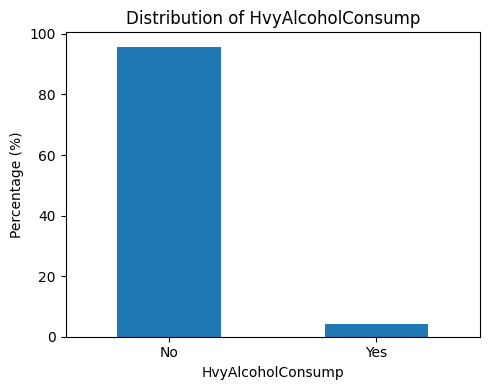

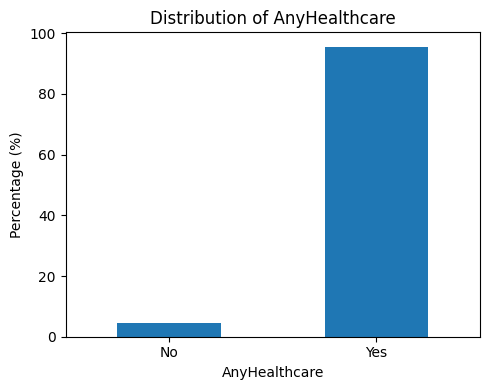

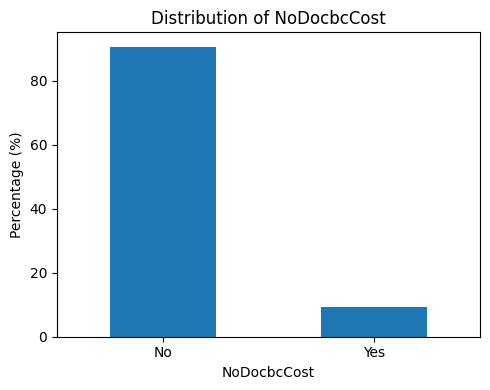

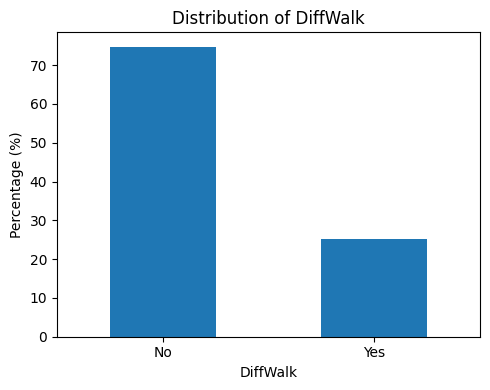

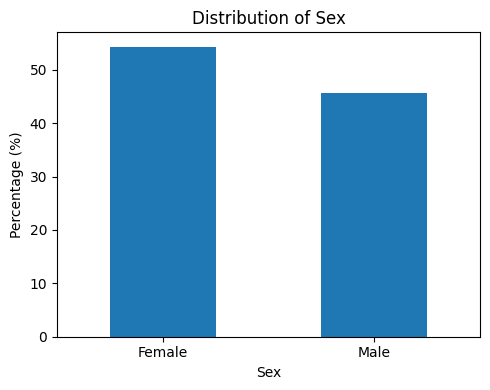

In [755]:
for feature in binary_features:

    percentages = (
        df[feature]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    percentages.index = percentages.index.map(binary_labels[feature])

    ax = percentages.plot(
        kind='bar',
        figsize=(5,4)
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.show()

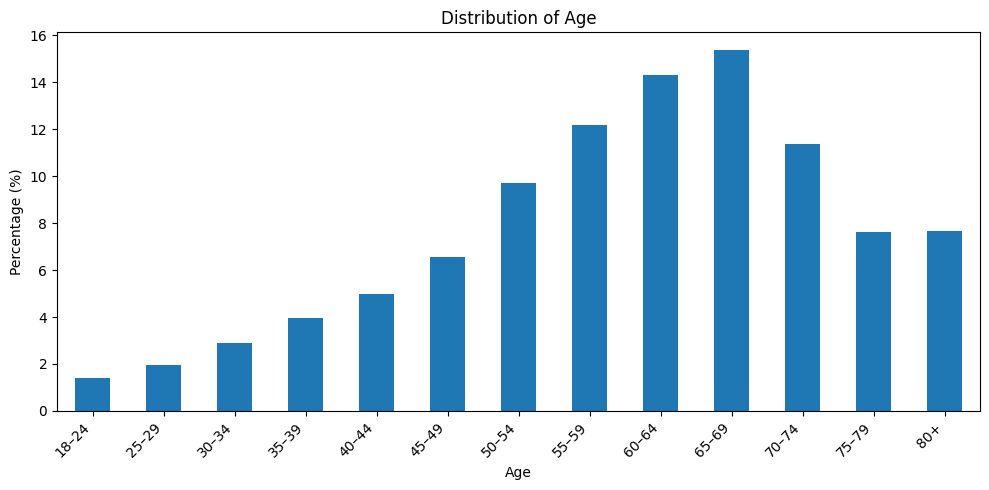

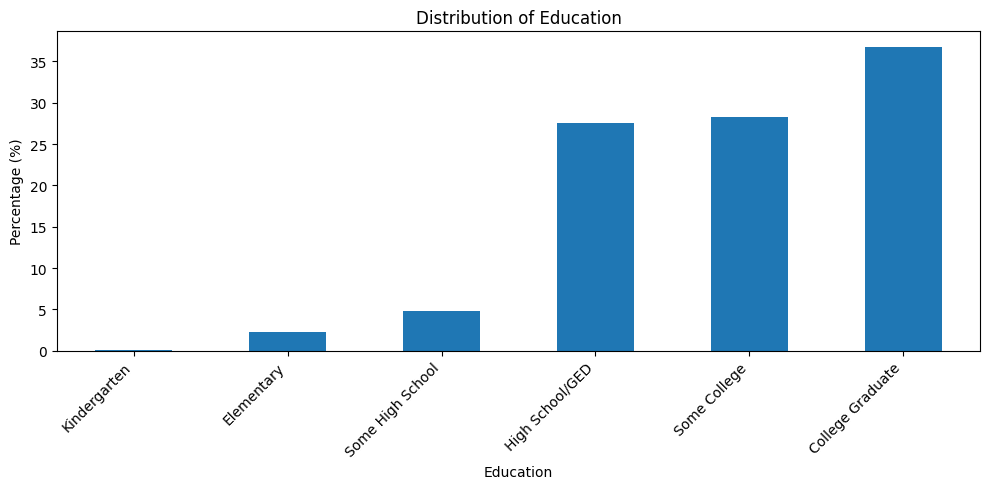

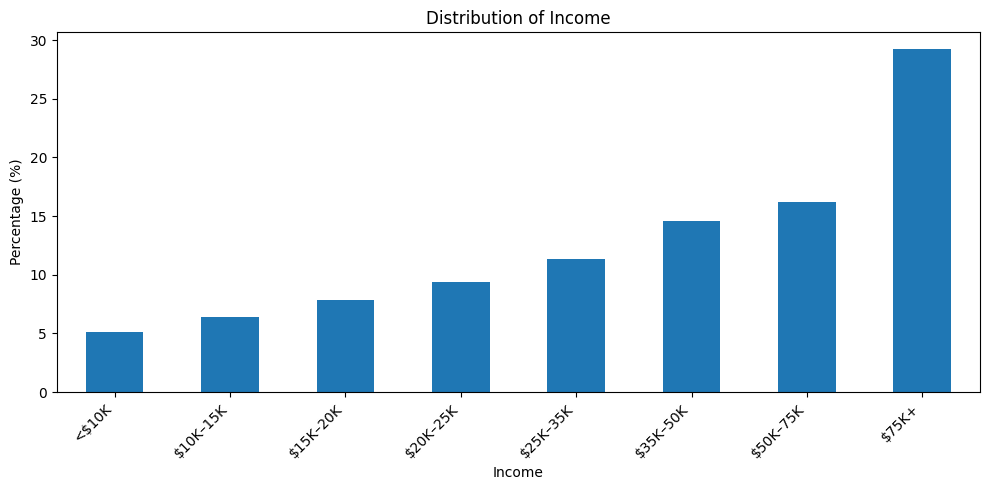

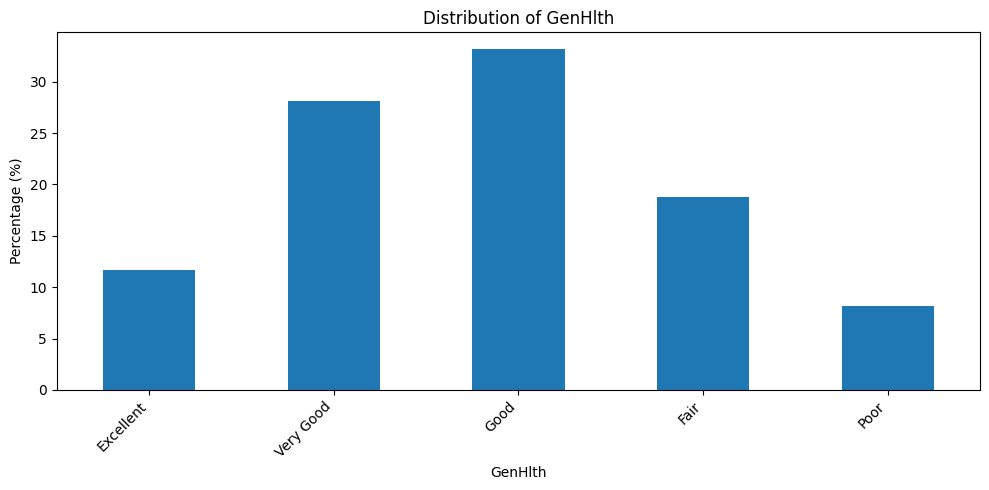

In [756]:
for feature in ordinal_features:

    percentages = (
        df_eda[feature]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    if feature == 'MentHlth' or feature == 'PhysHlth':
      continue

    percentages.index = percentages.index.map(ordinal_labels[feature])

    ax = percentages.plot(
        kind='bar',
        figsize=(10,5)
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()

### 4.2 Bivariate Analysis

Bivariate Analysis for binary features:

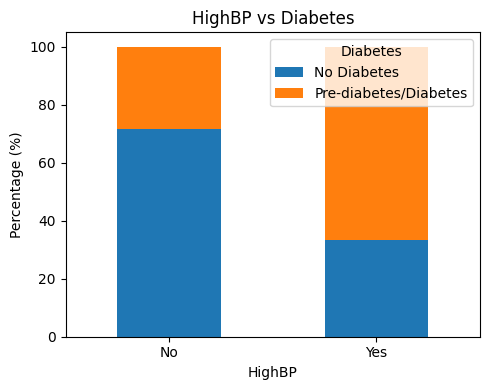

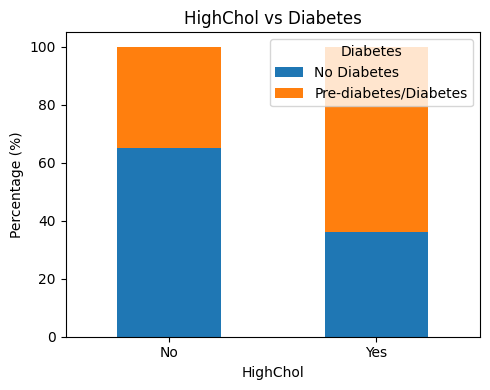

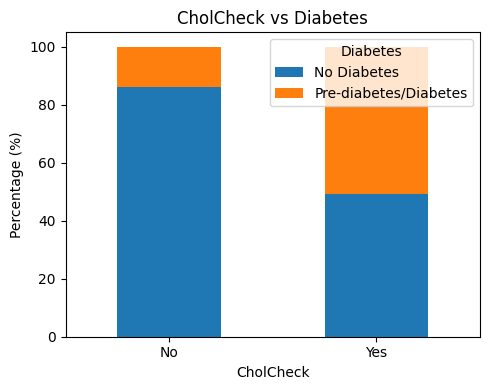

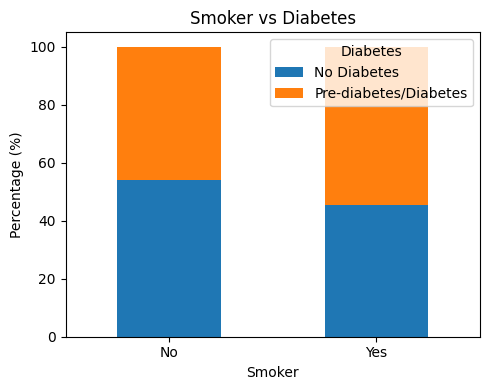

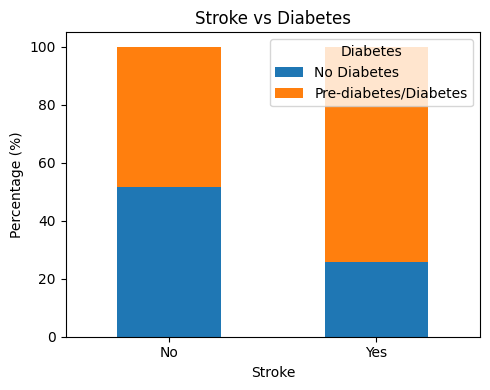

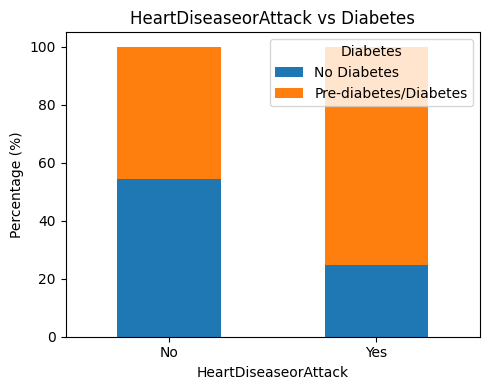

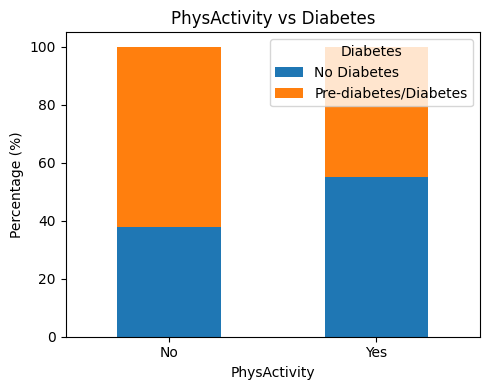

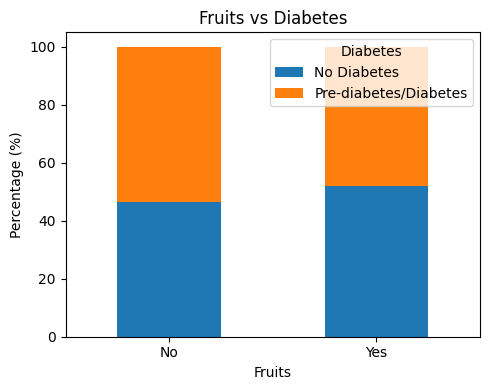

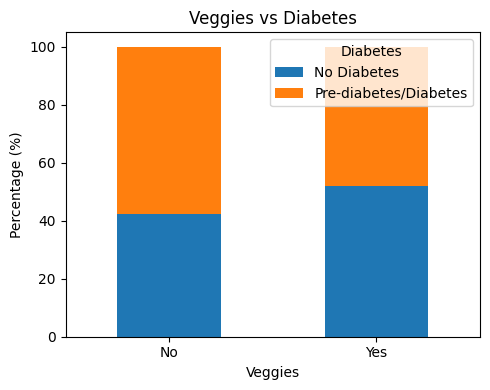

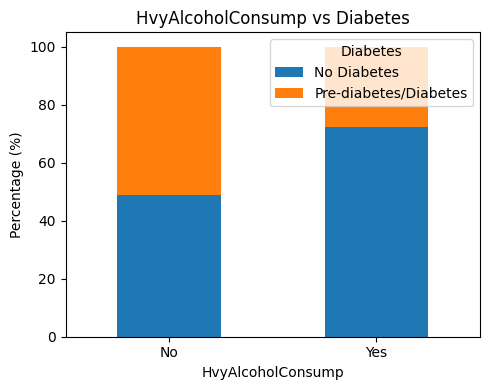

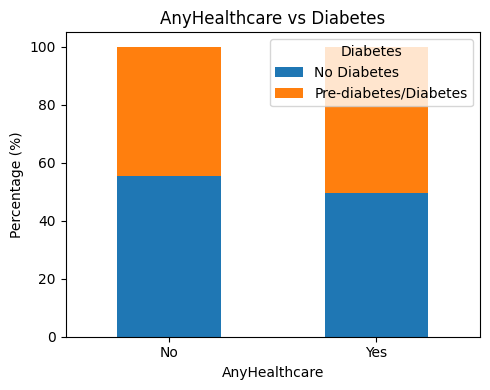

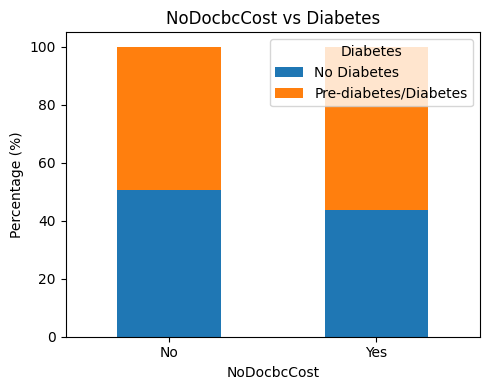

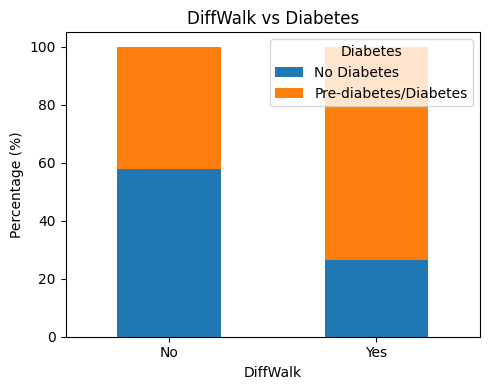

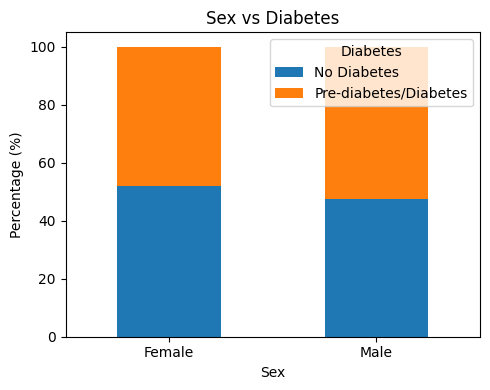

In [757]:
for feature in binary_features:

    table = pd.crosstab(
        df_eda[feature],
        df_eda['Diabetes_binary'],
        normalize='index'
    ) * 100

    table.index = table.index.map(binary_labels[feature])

    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    table.plot(
        kind='bar',
        stacked=True,
        figsize=(5,4)
    )

    plt.title(f'{feature} vs Diabetes')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Diabetes')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Bivariate analysis for ordinal features

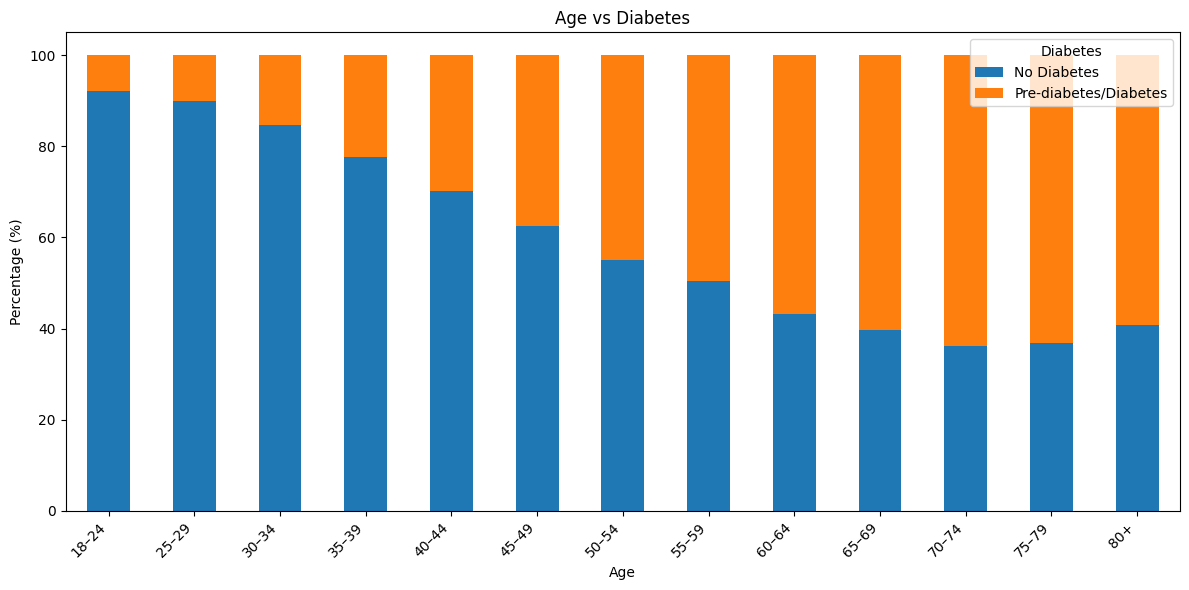

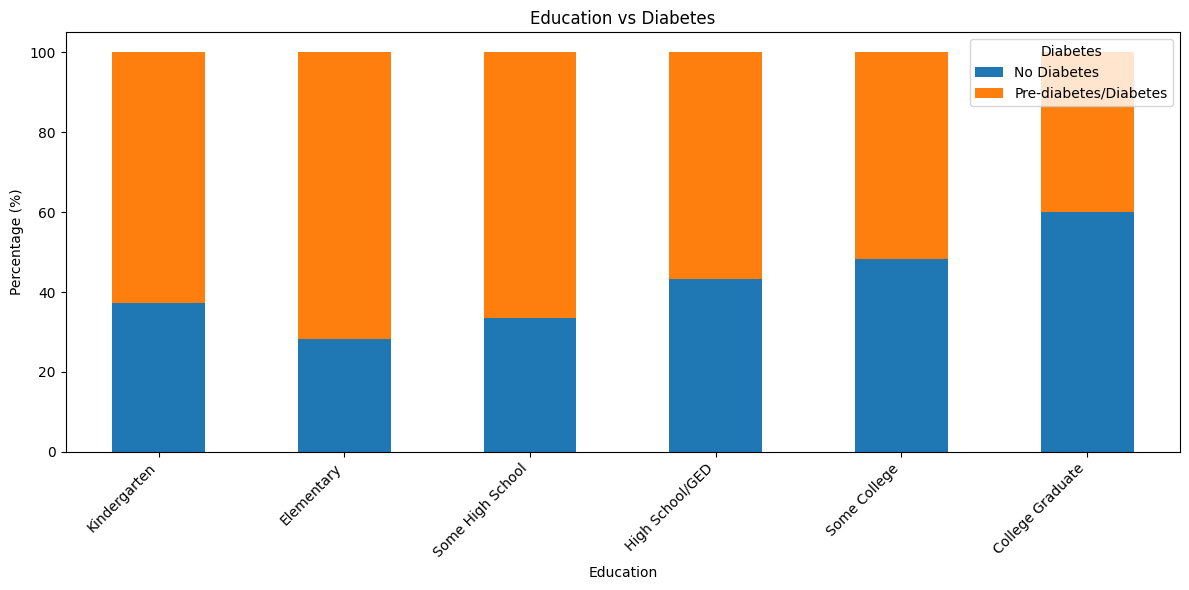

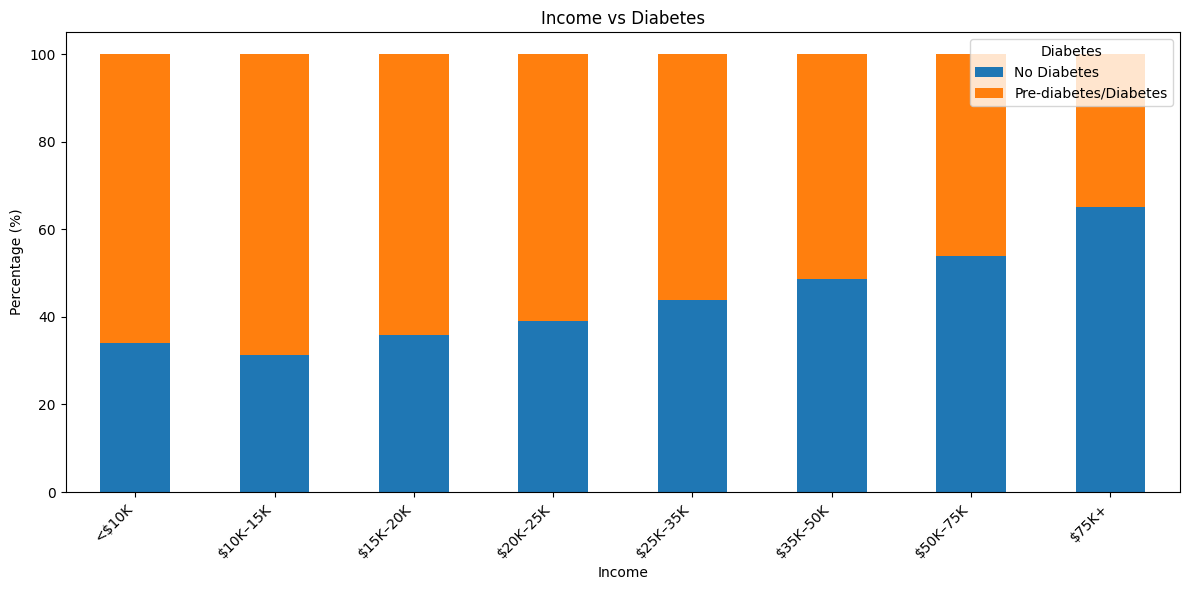

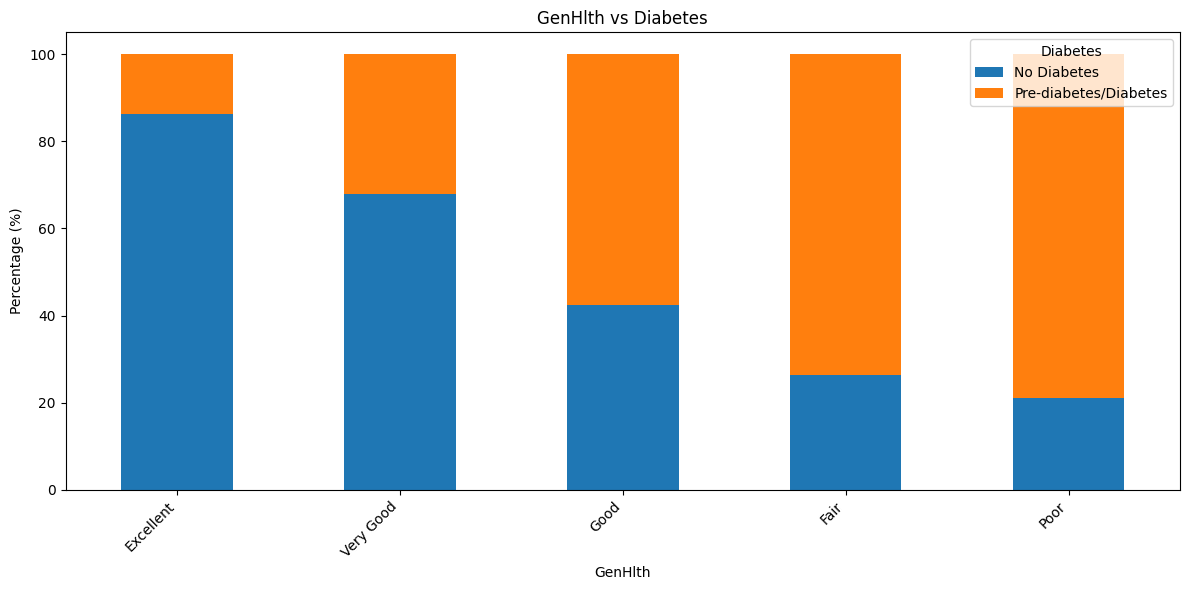

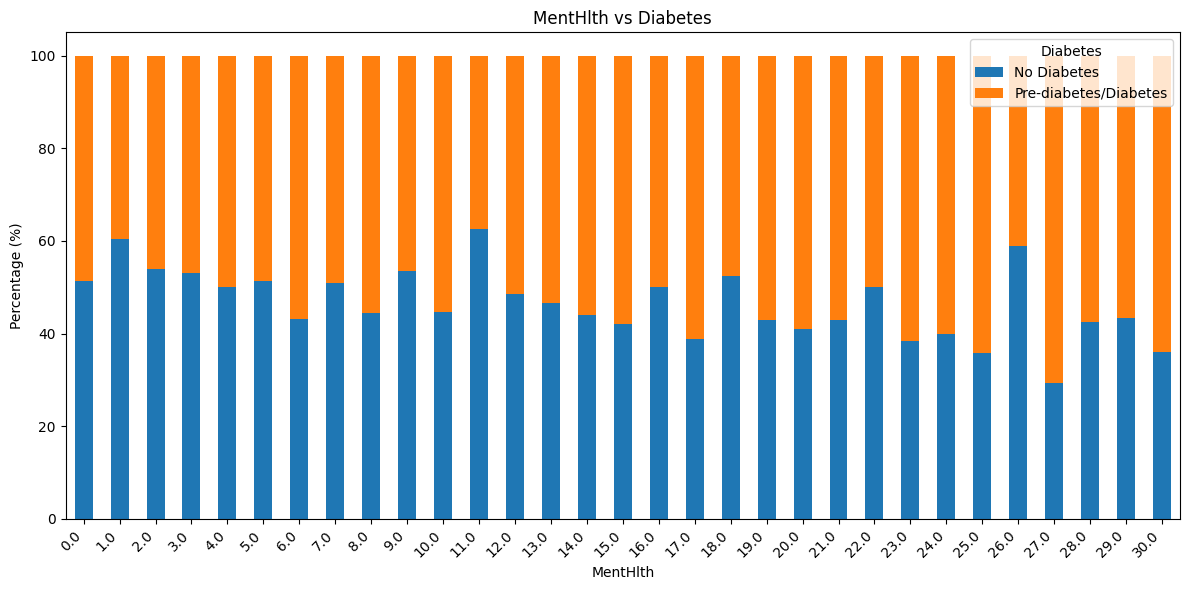

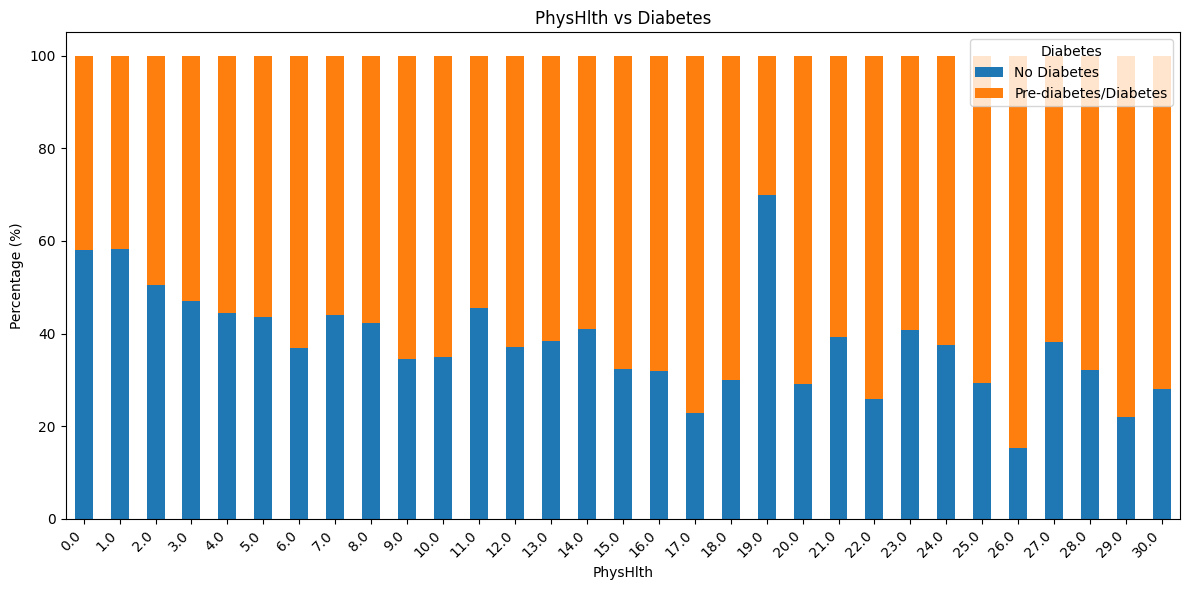

In [758]:
for feature in ordinal_features:

    table = pd.crosstab(
        df_eda[feature],
        df_eda['Diabetes_binary'],
        normalize='index'
    ) * 100

    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    # Replace numeric values with labels
    if feature in ordinal_labels:
        table.index = table.index.map(ordinal_labels[feature])

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f'{feature} vs Diabetes')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Diabetes')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Since `MentHlth` and `PhysHlth` are discrete numerical (count) variables rather than categorical ones, a box plot is more appropriate than a bar chart here:

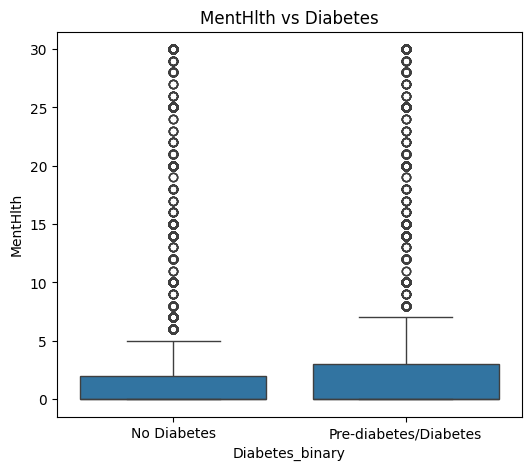

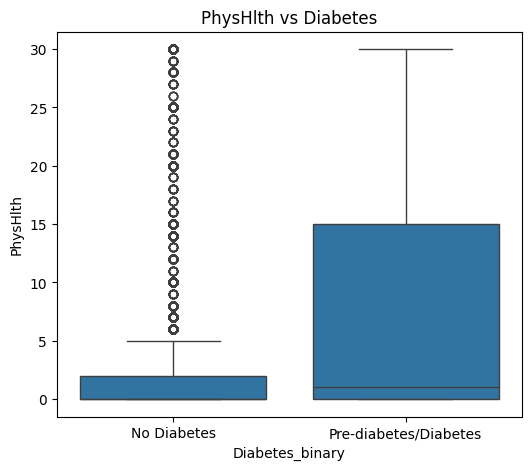

In [759]:
health_days = ['MentHlth', 'PhysHlth']

for feature in health_days:

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=df,
        x='Diabetes_binary',
        y=feature
    )

    plt.xticks(
        [0,1],
        ['No Diabetes','Pre-diabetes/Diabetes']
    )

    plt.title(f'{feature} vs Diabetes')

    plt.show()

Diabetic patients across BMI classes:

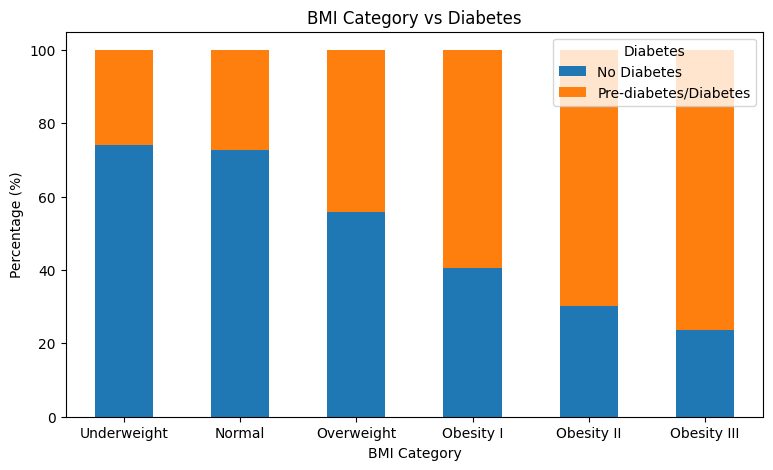

In [760]:
table = pd.crosstab(
    df_eda['BMI_Class'],
    df_eda['Diabetes_binary'],
    normalize='index'
) * 100

table.columns = ['No Diabetes','Pre-diabetes/Diabetes']

table.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title('BMI Category vs Diabetes')
plt.ylabel('Percentage (%)')
plt.xlabel('BMI Category')
plt.legend(title='Diabetes')
plt.xticks(rotation=0)

plt.show()

### 4.1 Multivariate Analysis

Correlation Heatmap

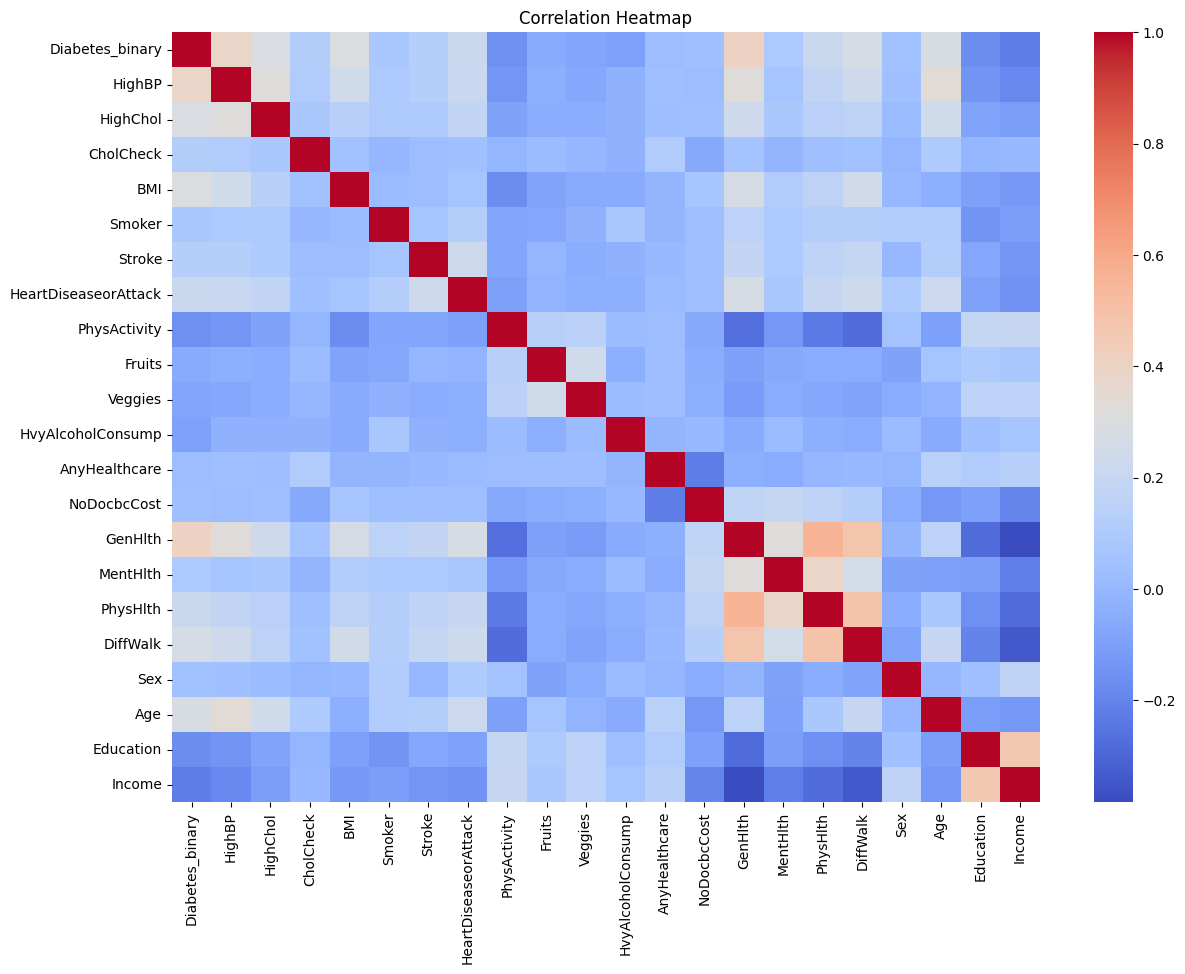

In [761]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Physical activity vs. diabetes, split by sex:

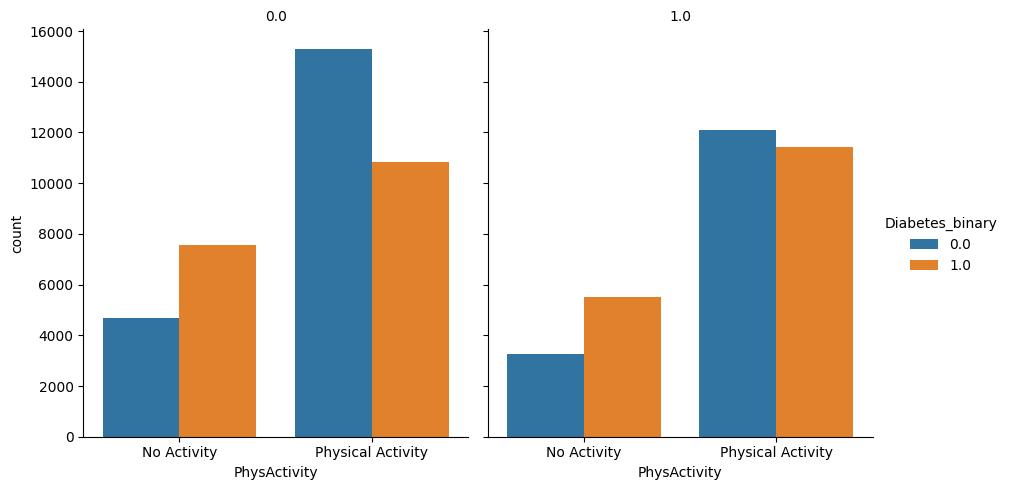

In [762]:
g = sns.catplot(
    data=df_eda,
    x='PhysActivity',
    hue='Diabetes_binary',
    col='Sex',
    kind='count',
    height=5,
    aspect=0.9
)

g.set_xticklabels(['No Activity','Physical Activity'])
g.set_titles("Female" if "{col_name}"=="0.0" else "{col_name}")

BMI distribution across age groups, split by diabetes status:

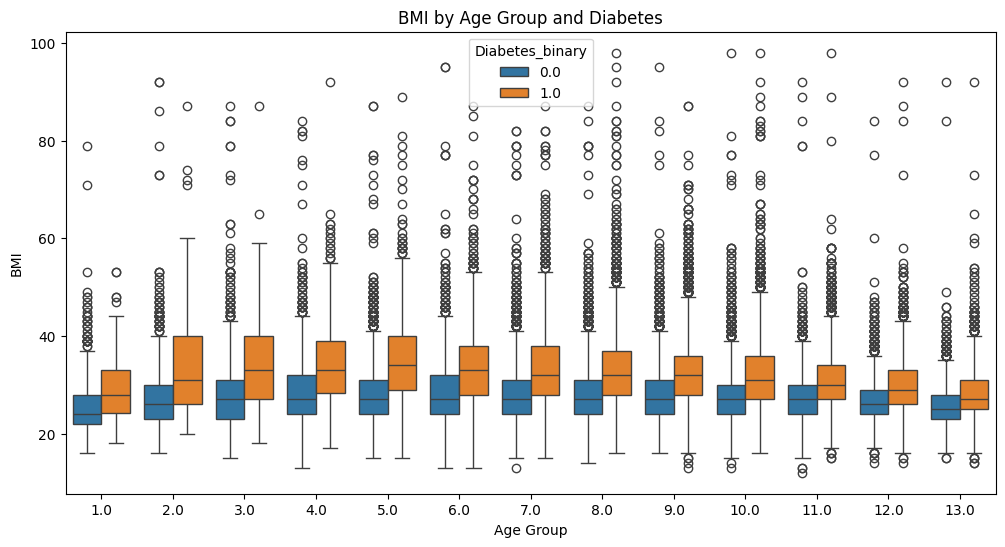

In [763]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_eda,
    x='Age',
    y='BMI',
    hue='Diabetes_binary'
)

plt.title("BMI by Age Group and Diabetes")
plt.xlabel("Age Group")
plt.ylabel("BMI")

plt.show()

General health rating vs. diabetes:

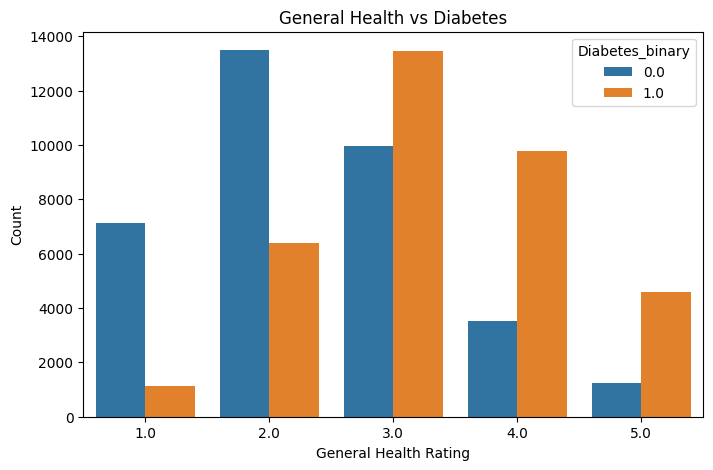

In [764]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x='GenHlth',
    hue='Diabetes_binary'
)

plt.xlabel("General Health Rating")
plt.ylabel("Count")
plt.title("General Health vs Diabetes")

plt.show()

General health rating vs. diabetes, split by sex:

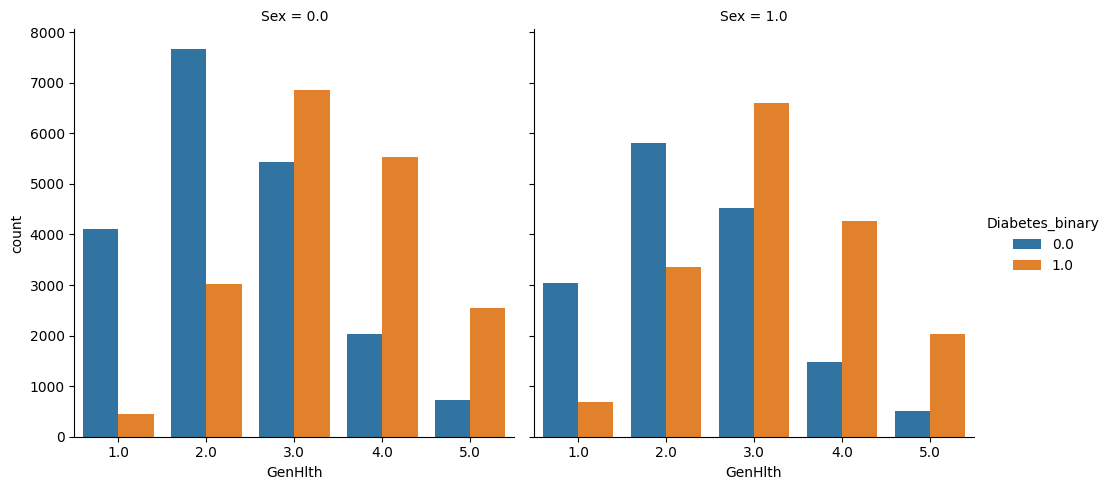

In [765]:
sns.catplot(
    data=df_eda,
    x='GenHlth',
    hue='Diabetes_binary',
    col='Sex',
    kind='count'
)

BMI vs. mental health days, colored by diabetes status:

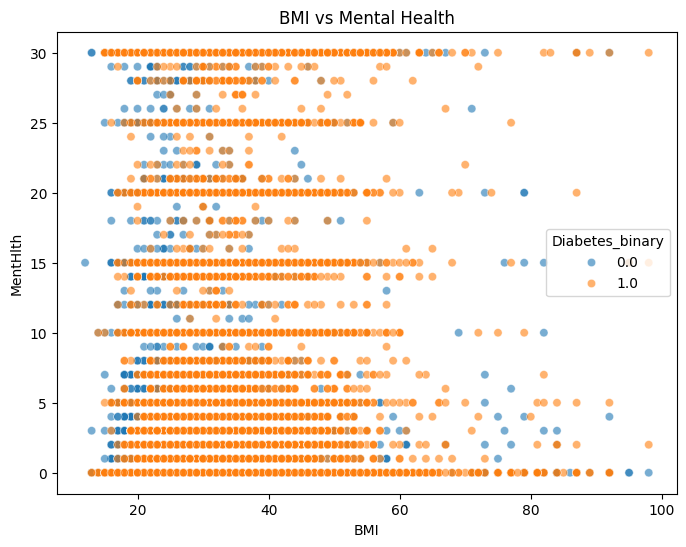

In [766]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='BMI',
    y='MentHlth',
    hue='Diabetes_binary',
    alpha=0.6
)

plt.title("BMI vs Mental Health")
plt.show()

BMI distribution split by sex and diabetes status:

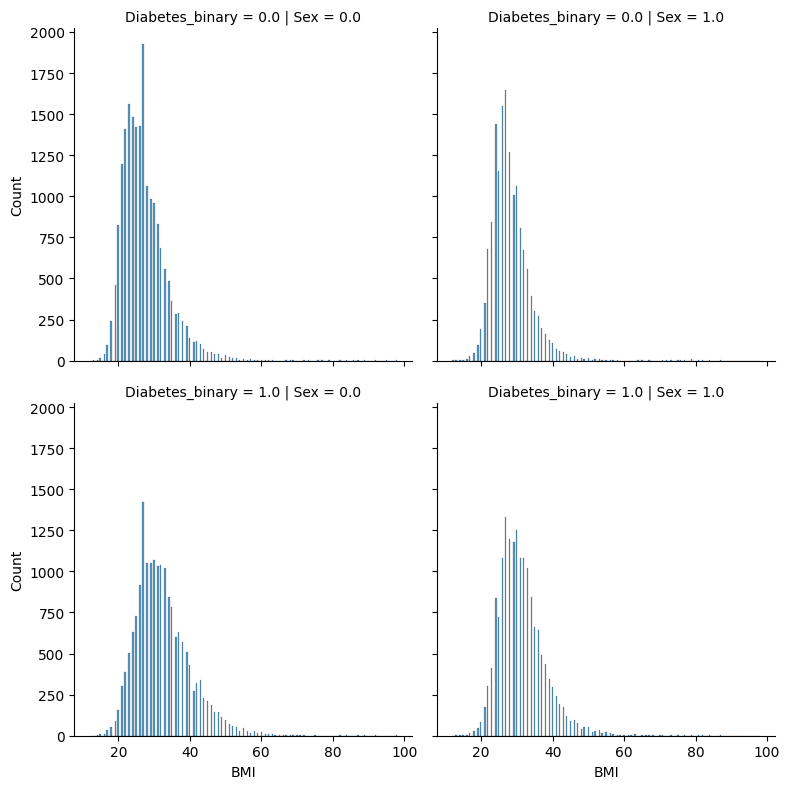

In [767]:
sns.displot(
    data=df,
    x='BMI',
    col='Sex',
    row='Diabetes_binary',
    height=4
)

Average BMI by age group and diabetes status:

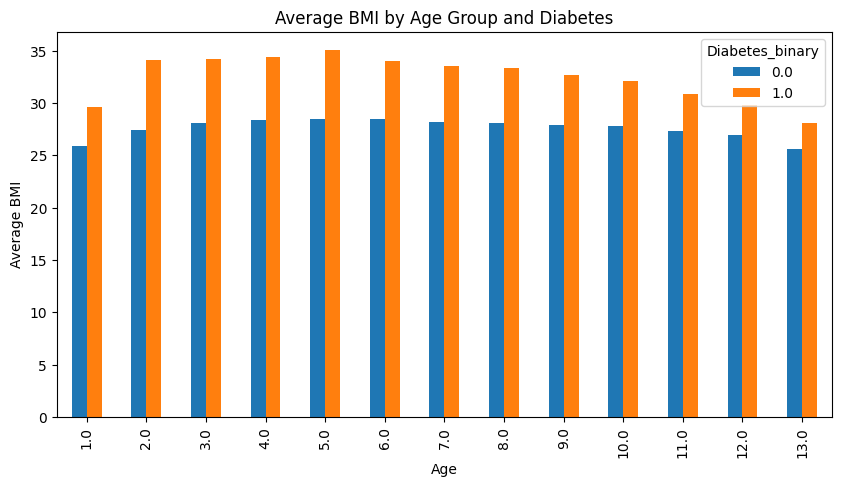

In [768]:
pivot = df.pivot_table(
    values='BMI',
    index='Age',
    columns='Diabetes_binary',
    aggfunc='mean'
)

pivot.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average BMI")
plt.title("Average BMI by Age Group and Diabetes")
plt.show()

### 4.4 Anomaly in BMI??

Checking whether the high-BMI values behave consistently with other diabetes risk factors (age, general health, heart disease, difficulty walking, physical activity) — if so, they are likely genuine severe-obesity cases rather than data errors:

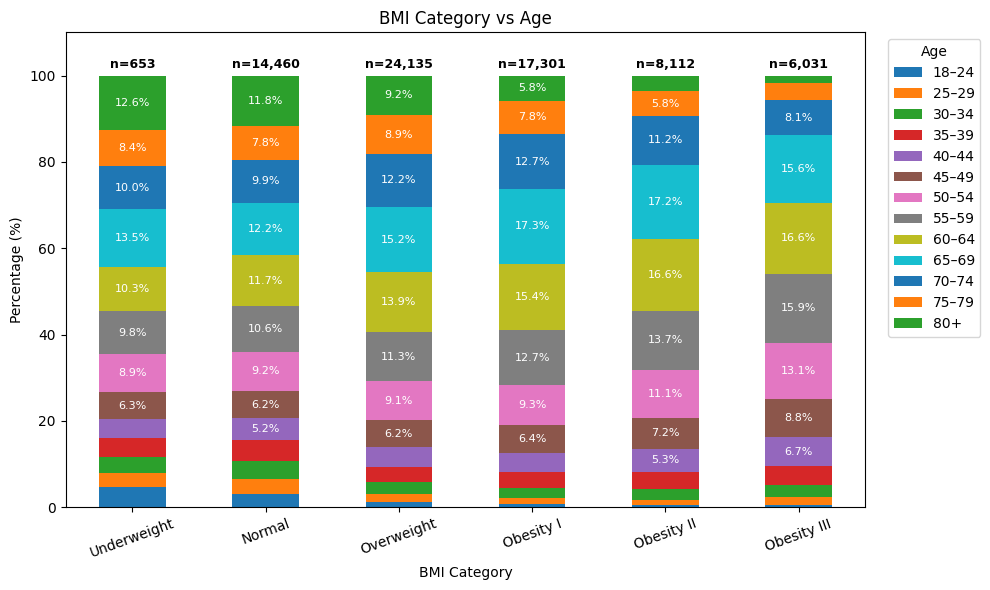

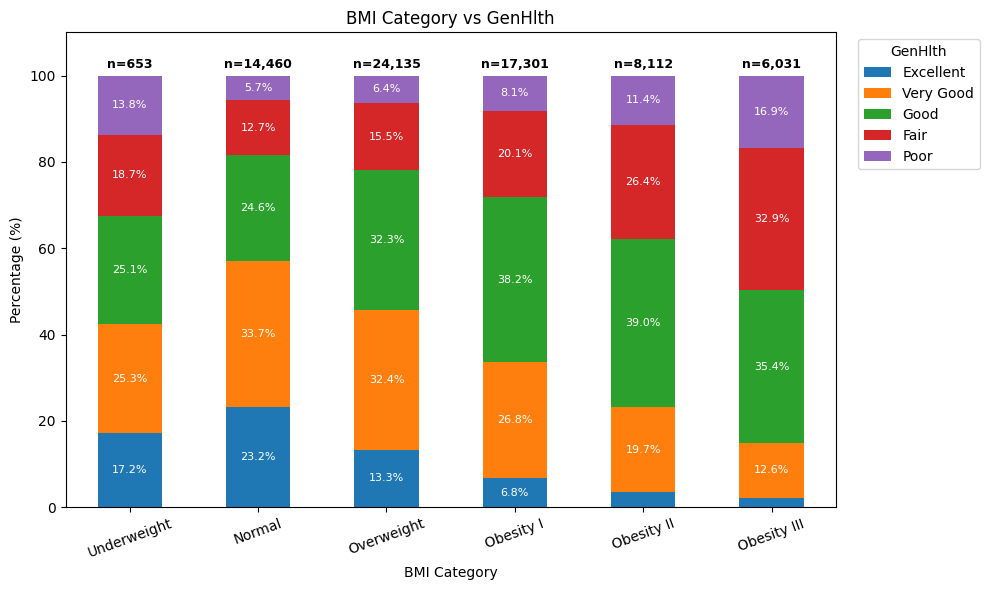

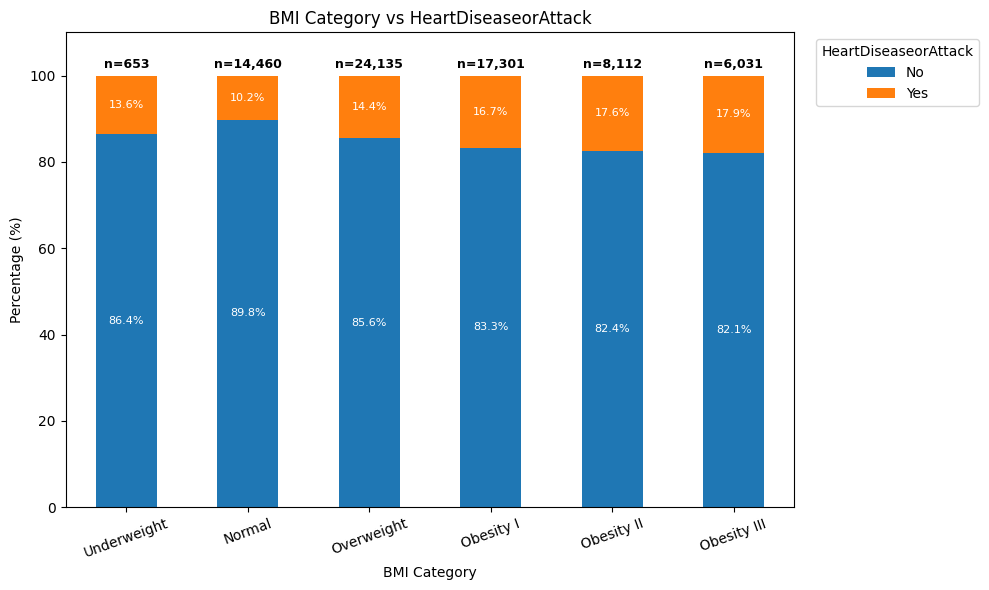

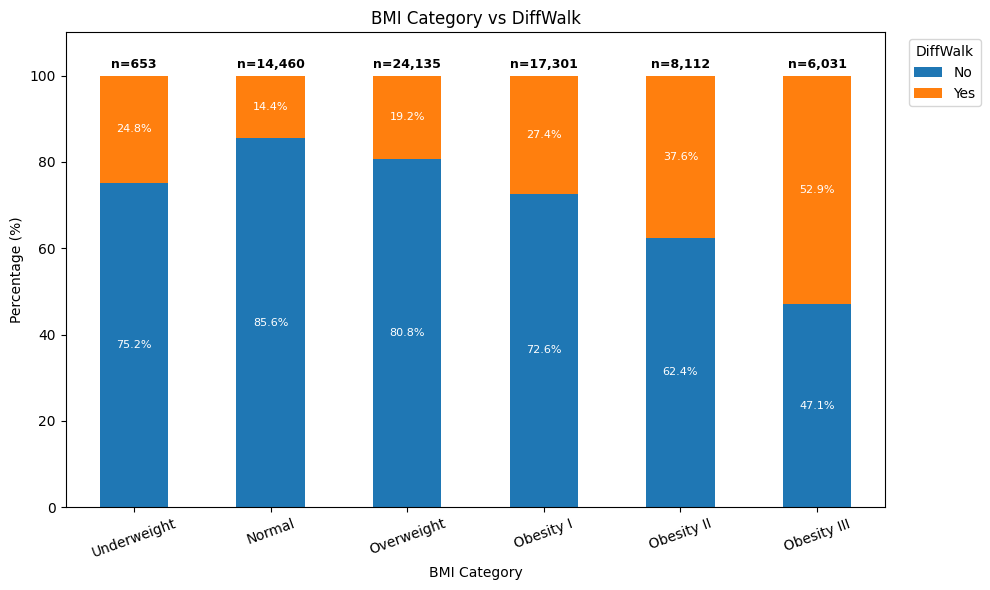

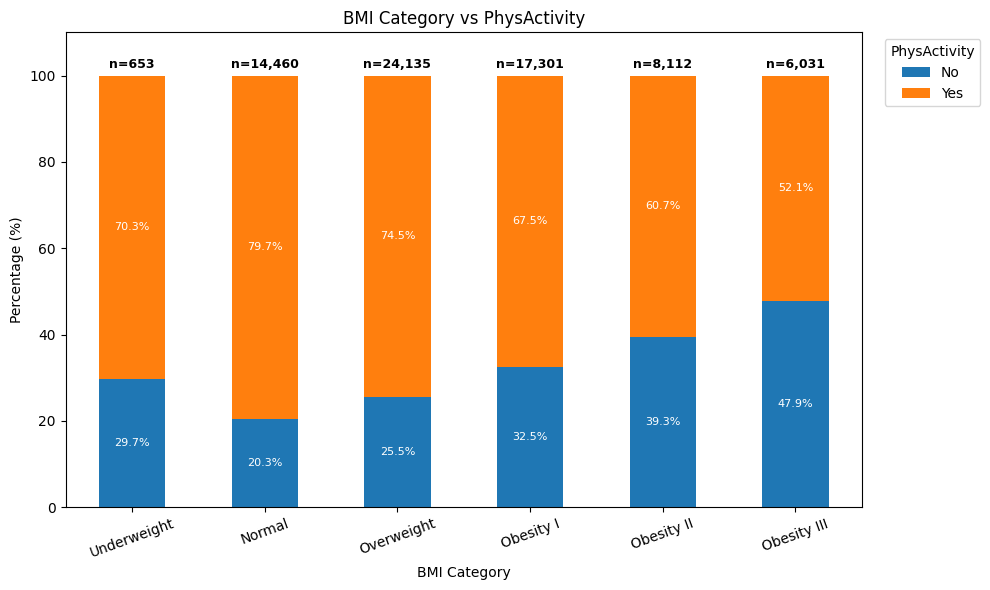

In [769]:
features = [
    'Age',
    'GenHlth',
    'HeartDiseaseorAttack',
    'DiffWalk',
    'PhysActivity'
]

feature_labels = {
    'Age': ordinal_labels['Age'],
    'GenHlth': ordinal_labels['GenHlth'],
    'HeartDiseaseorAttack': binary_labels['HeartDiseaseorAttack'],
    'DiffWalk': binary_labels['DiffWalk'],
    'PhysActivity': binary_labels['PhysActivity'],
}



for feature in features:

    table = pd.crosstab(
        df_eda['BMI_Class'],
        df_eda[feature],
        normalize='index'
    ) * 100

    table = table.reindex(bmi_order)

    # Replace numeric column labels with descriptive labels
    table.columns = [feature_labels[feature][c] for c in table.columns]

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6)
    )

    # -------------------------
    # Percentage labels
    # -------------------------
    for container in ax.containers:

        labels = [
            f'{bar.get_height():.1f}%'
            if bar.get_height() >= 5 else ''
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=8,
            color='white'
        )

    # -------------------------
    # Counts above each BMI class
    # -------------------------
    counts = (
        df_eda['BMI_Class']
        .value_counts()
        .reindex(bmi_order)
    )

    for i, count in enumerate(counts):
        ax.text(
            i,
            101,
            f'n={count:,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_ylim(0,110)

    plt.title(f'BMI Category vs {feature}')
    plt.xlabel('BMI Category')
    plt.ylabel('Percentage (%)')
    plt.legend(
        title=feature,
        bbox_to_anchor=(1.02,1),
        loc='upper left'
    )

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Comparing the BMI–diabetes relationship separately for people with and without difficulty walking, to see if the pattern holds within each group:

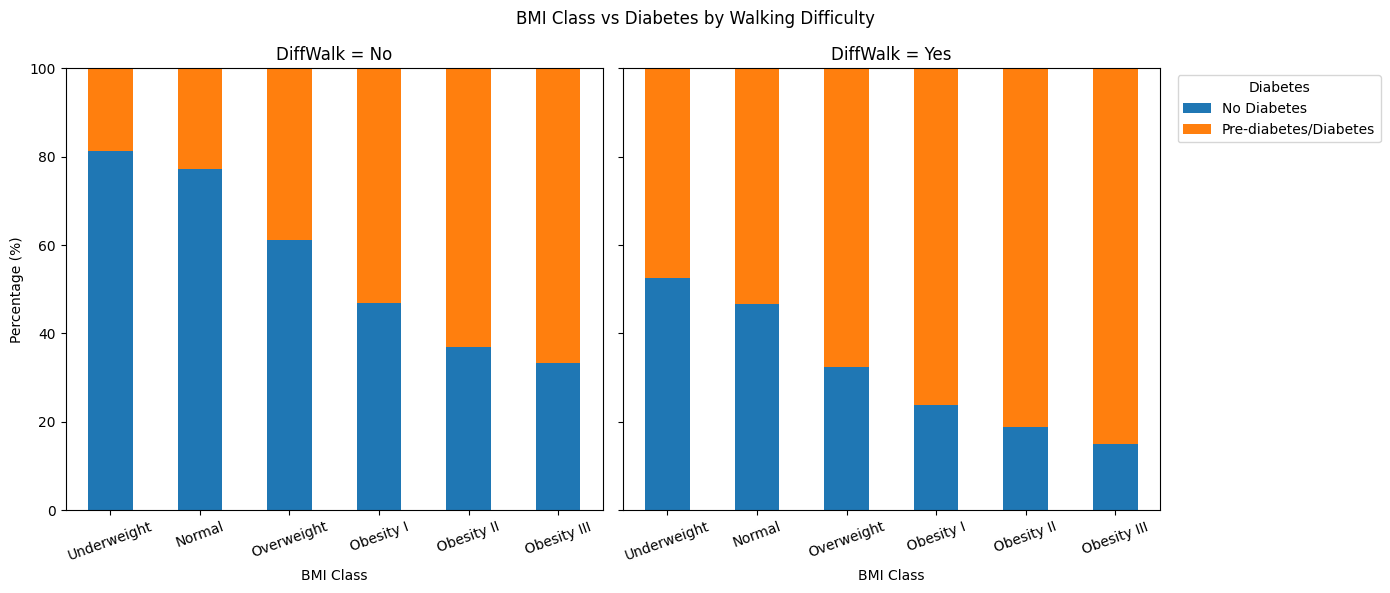

In [770]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, diff in enumerate([0, 1]):

    subset = df_eda[df_eda['DiffWalk'] == diff]

    table = pd.crosstab(
        subset['BMI_Class'],
        subset['Diabetes_binary'],
        normalize='index'
    ) * 100

    table = table.reindex(bmi_order)
    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    table.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(
        f"DiffWalk = {'No' if diff == 0 else 'Yes'}"
    )
    axes[i].set_xlabel('BMI Class')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=20)

axes[1].legend(
    title='Diabetes',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.suptitle('BMI Class vs Diabetes by Walking Difficulty')
plt.tight_layout()
plt.show()

Relationship between BMI category and heart disease/attack history:

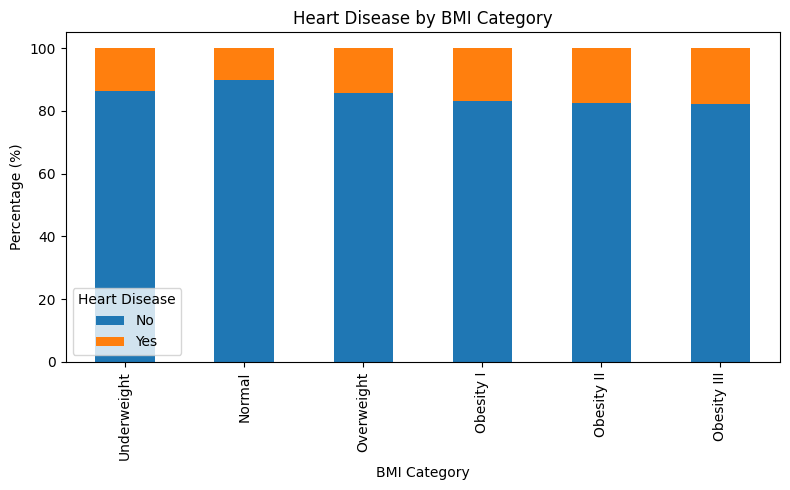

In [771]:
table = pd.crosstab(
    df_eda['BMI_Class'],
    df_eda['HeartDiseaseorAttack'],
    normalize='index'
) * 100

table.columns = ['No','Yes']

table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Heart Disease by BMI Category')
plt.ylabel('Percentage (%)')
plt.xlabel('BMI Category')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

##5. Data Preprocessing

### 5.1 Outlier Handling

A boxplot identified extreme values in the BMI feature. These observations were further investigated through univariate, bivariate, and multivariate analyses. The extreme BMI values were found to exhibit meaningful relationships with diabetes prevalence, general health, physical activity, heart disease, and walking difficulty, indicating that they represent genuine cases of severe obesity rather than data entry errors. Since BMI is a clinically significant predictor of diabetes, these observations were retained. No outlier treatment was applied. The remaining numerical variables (MentHlth and PhysHlth) are bounded count variables, and Age is an ordinal categorical feature; therefore, no outlier handling was required for these variables.

### 5.2 Feature and Target Separation

In [772]:
#separate features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

Confirm the shapes of the separated features (`X`) and target (`y`):

In [773]:
print(X.shape)
print(y.shape)

(70692, 21)
(70692,)


### 5.3 Train-Test Split

In [774]:
#train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 5.4 Scaling

Feature scaling was applied to the numeric measurement and count variables (BMI, MentHlth, and PhysHlth) using StandardScaler. These variables have different numerical ranges, and scaling helps distance-based and gradient-based machine learning algorithms perform more effectively. Binary and ordinal categorical variables were left unchanged because they represent encoded categories rather than continuous measurements.

In [775]:
from sklearn.preprocessing import StandardScaler

# Create a scaler
scaler = StandardScaler()

# Make a copy of the features
X_scaled = X.copy()

# Scale only continuous numerical columns
columns_to_scale = ["BMI", "MentHlth", "PhysHlth"]

X_train[columns_to_scale] = scaler.fit_transform(
    X_train[columns_to_scale]
)

X_test[columns_to_scale] = scaler.transform(
    X_test[columns_to_scale]
)

Preview of the scaled training data:

In [776]:
X_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
47977,1.0,0.0,1.0,-0.119897,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,-0.459731,-0.575632,0.0,1.0,10.0,6.0,8.0
2676,0.0,1.0,1.0,-0.822423,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,3.0,1.386706,0.023063,0.0,0.0,7.0,5.0,1.0
35637,1.0,0.0,1.0,1.706673,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,3.0,-0.459731,0.422192,1.0,0.0,11.0,5.0,4.0
52420,1.0,1.0,1.0,0.020609,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,3.0,-0.459731,-0.475849,0.0,0.0,10.0,5.0,5.0
12445,1.0,0.0,1.0,0.723136,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,3.0,-0.459731,-0.575632,0.0,1.0,6.0,4.0,5.0


### 5.3 Feature Selection

##### 5.3.1 Correlation Analysis

**Correlation analysis is skipped** for feature selection, since the EDA did not reveal any strongly correlated feature pairs.

##### 5.3.2 Mutual Information

Instead, feature relevance is assessed using **Mutual Information**, which can also capture non-linear relationships between each feature and the target. This is fit on `X_train`/`y_train` only (not the full dataset) to avoid leaking information from the test set into the feature-selection step.

In [777]:
from sklearn.feature_selection import mutual_info_classif


mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = (
    pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information": mi
    })
    .sort_values("Mutual Information", ascending=False)
)

mi_scores

,Feature,Mutual Information
13,GenHlth,0.093949
0,HighBP,0.083612
3,BMI,0.058415
18,Age,0.045789
1,HighChol,0.045053
16,DiffWalk,0.040397
15,PhysHlth,0.029376
6,HeartDiseaseorAttack,0.025650
20,Income,0.025170
7,PhysActivity,0.019485


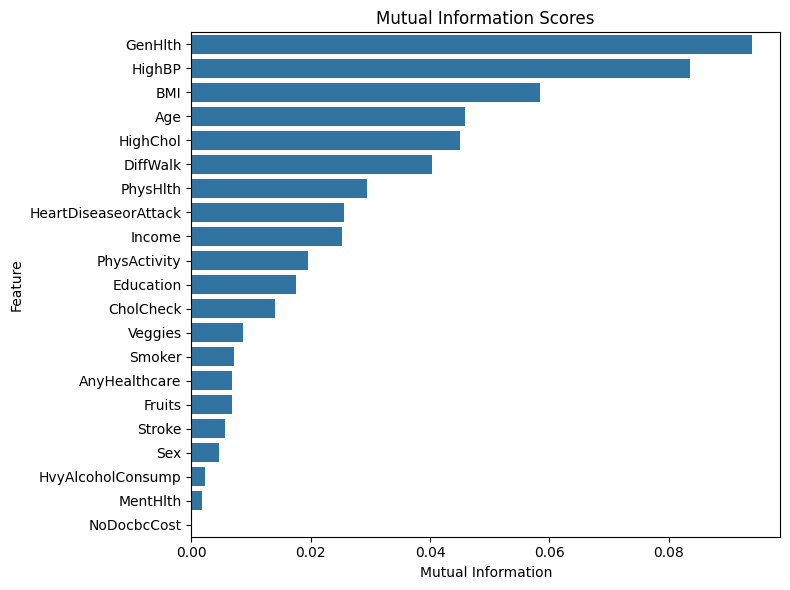

In [778]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=mi_scores,
    x="Mutual Information",
    y="Feature"
)

plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

`GenHlth`, `HighBP`, and `BMI` come out as the strongest individual predictors of diabetes by mutual information, while `NoDocbcCost` contributes virtually no information on its own. This broadly agrees with the patterns seen during EDA and can guide later feature-selection decisions.

##### 5.3.3 Using SelectKBest

To formalize the ranking from the Mutual Information analysis above into an actual feature-selection step, we use scikit-learn's `SelectKBest`. It scores every feature independently and keeps only the top `k`.

This is fit on `X_train`/`y_train` only (not the full dataset) to avoid leaking information from the test set into the feature-selection step.

In [779]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 15  # number of top features to keep

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

kbest_scores = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "F-Score": selector.scores_,
        "P-value": selector.pvalues_
    })
    .sort_values("F-Score", ascending=False)
)

kbest_scores

,Feature,F-Score,P-value
13,GenHlth,11441.080616,0.000000e+00
0,HighBP,9562.554546,0.000000e+00
3,BMI,5317.424674,0.000000e+00
1,HighChol,5237.038920,0.000000e+00
18,Age,4744.489828,0.000000e+00
16,DiffWalk,4468.811167,0.000000e+00
20,Income,2947.090033,0.000000e+00
6,HeartDiseaseorAttack,2693.400453,0.000000e+00
15,PhysHlth,2692.759016,0.000000e+00
19,Education,1645.040919,0.000000e+00


Visualizing the F-scores, same style as the Mutual Information plot above so the two are easy to compare:

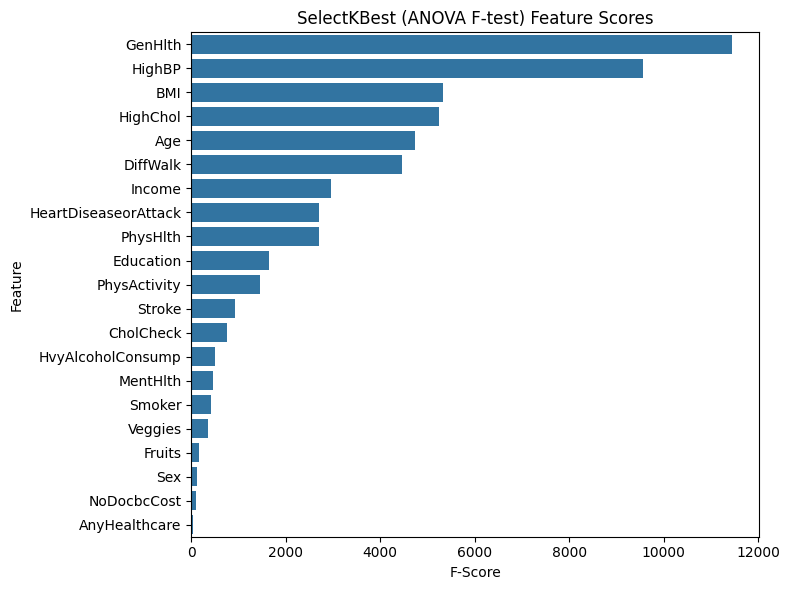

In [780]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=kbest_scores,
    x="F-Score",
    y="Feature"
)

plt.title(f"SelectKBest (ANOVA F-test) Feature Scores")
plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The top-`k` selected features (in original column order):

In [781]:
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
dropped_features = X_train.columns[~selected_mask]

print(f"Selected ({len(selected_features)}):", list(selected_features))
print(f"Dropped ({len(dropped_features)}):", list(dropped_features))

Selected (15): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
Dropped (6): ['Smoker', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost', 'Sex']


Reducing the train/test feature sets to the selected columns, ready to feed into modeling:

In [782]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

X_train_selected.shape, X_test_selected.shape

((56553, 15), (14139, 15))

**Comparing with Mutual Information:** `GenHlth`, `HighBP`, `BMI`, `HighChol`, `Age`, and `DiffWalk` rank highly under both Mutual Information and the ANOVA F-test, which is a good sign; two different scoring methods agreeing on the strongest predictors gives more confidence in the ranking than either one alone. Features like `NoDocbcCost` and `HvyAlcoholConsump` score low under both methods and are the most likely candidates to drop if a smaller feature set is needed. The exact value of `k` above is a starting point, it can be tuned later based on downstream model performance (e.g. cross-validated accuracy/AUC for a few different `k` values).